# Load and Inspect Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datasets import load_dataset

dataset = load_dataset("Ateeqq/AI-and-Human-Generated-Text")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/33.9M [00:00<?, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/22930 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5732 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'abstract', 'label'],
        num_rows: 22930
    })
    test: Dataset({
        features: ['title', 'abstract', 'label'],
        num_rows: 5732
    })
})


In [2]:
# Check the structure
print(dataset['train'].features)
print(dataset['train'][0])

train_df = dataset['train'].to_pandas()
test_full_df = dataset['test'].to_pandas()

print("=== Train Label Distribution ===")
print(train_df['label'].value_counts().rename({0: 'Human', 1: 'AI'}))
print("\n=== Test Label Distribution ===")
print(test_full_df['label'].value_counts().rename({0: 'Human', 1: 'AI'}))

{'title': Value('string'), 'abstract': Value('string'), 'label': Value('int64')}
{'title': 'Epigenetic inheritance of circadian period in clonal cells', 'abstract': '\n\nThis study focuses on the epigenetic inheritance of circadian period in clonal cells. In recent years, evidence has been emerging that implicates epigenetics as a fundamental factor driving cellular rhythms and other physiological processes within organisms. The findings from these studies indicate the potential for episodic changes to be maintained across generations via an inheritable memory embodied at a subcellular level by genetic mechanisms that operate independently of traditional Mendelian laws. Our investigations have used a novel approach to uncover how this inherited epigenetic component can affect the circadian periods of individual clonal cell lines over time. To achieve our objectives, we developed modified culture growth conditions combined with single-cell RNA sequencing techniques and chromatin immunop

In [3]:
print(train_df['abstract'].iloc[0])
print(train_df['abstract'].iloc[1])
print(train_df['abstract'].iloc[2])
print(train_df['abstract'].iloc[4])
train_df.head(20)
test_full_df.head(10)

# Check how many abstracts start with \n\n across all splits
for name, df in [('train', train_df), ('test', test_full_df)]:
    n = df['abstract'].str.startswith('\n\n').sum()
    print(f"{name}: {n} / {len(df)} abstracts start with \\n\\n")

# for whatever reason, it seems like most AI responses have "\n\n" at their beginning

# Strip leading \n\n from all splits
for df in [train_df, test_full_df]:
    df['abstract'] = df['abstract'].str.lstrip('\n')

print("After trimming:")
for name, df in [('train', train_df), ('test', test_full_df)]:
    n = df['abstract'].str.startswith('\n\n').sum()
    print(f"{name}: {n} / {len(df)} abstracts start with \\n\\n")




This study focuses on the epigenetic inheritance of circadian period in clonal cells. In recent years, evidence has been emerging that implicates epigenetics as a fundamental factor driving cellular rhythms and other physiological processes within organisms. The findings from these studies indicate the potential for episodic changes to be maintained across generations via an inheritable memory embodied at a subcellular level by genetic mechanisms that operate independently of traditional Mendelian laws. Our investigations have used a novel approach to uncover how this inherited epigenetic component can affect the circadian periods of individual clonal cell lines over time. To achieve our objectives, we developed modified culture growth conditions combined with single-cell RNA sequencing techniques and chromatin immunoprecipitation assays to observe advances in temporal regulation patterns. These results advance our understanding of heredity from a classical genetic perspective toward

# Metadata Computation

In [4]:
import re

def add_metadata(df):
    # Word & char lengths
    df['abstract_word_length'] = df['abstract'].str.split().str.len()
    df['abstract_char_length'] = df['abstract'].str.len()
    df['title_word_length']    = df['title'].str.split().str.len()
    df['title_char_length']    = df['title'].str.len()

    # Average sentence length (words & chars) for abstracts
    def avg_sent_word_len(text):
        sents = re.split(r'(?<=[.!?])\s+', str(text).strip())
        sents = [s for s in sents if s]
        return np.mean([len(s.split()) for s in sents]) if sents else 0

    def avg_sent_char_len(text):
        sents = re.split(r'(?<=[.!?])\s+', str(text).strip())
        sents = [s for s in sents if s]
        return np.mean([len(s) for s in sents]) if sents else 0

    df['abstract_avg_sent_word_len'] = df['abstract'].apply(avg_sent_word_len)
    df['abstract_avg_sent_char_len'] = df['abstract'].apply(avg_sent_char_len)

    # Ratio: avg sentence char length / avg sentence word length (avg chars per word)
    df['abstract_avg_chars_per_word'] = (
        df['abstract_avg_sent_char_len'] / df['abstract_avg_sent_word_len'].replace(0, np.nan)
    )
    return df

train_df    = add_metadata(train_df)
test_full_df = add_metadata(test_full_df)

print(train_df[['abstract_word_length','abstract_char_length',
                 'title_word_length','title_char_length',
                 'abstract_avg_sent_word_len','abstract_avg_sent_char_len',
                 'abstract_avg_chars_per_word']].describe())

train_df.head(5)

       abstract_word_length  abstract_char_length  title_word_length  \
count          22930.000000          22930.000000       22930.000000   
mean             189.814261           1363.317096          13.643611   
std               93.831453            717.281231           5.289539   
min                3.000000             17.000000           1.000000   
25%              136.000000            983.000000          10.000000   
50%              175.000000           1257.000000          13.000000   
75%              228.000000           1610.750000          17.000000   
max             4642.000000          33894.000000          56.000000   

       title_char_length  abstract_avg_sent_word_len  \
count       22930.000000                22930.000000   
mean          103.406367                   26.894269   
std            39.613026                   10.055688   
min             4.000000                    2.363636   
25%            76.000000                   21.777778   
50%           1

,title,abstract,label,abstract_word_length,abstract_char_length,title_word_length,title_char_length,abstract_avg_sent_word_len,abstract_avg_sent_char_len,abstract_avg_chars_per_word
0,Epigenetic inheritance of circadian period in ...,This study focuses on the epigenetic inheritan...,1,195,1469,8,58,27.857143,209.000,7.502564
1,Pediatric Airway Stent Designed to Facilitate ...,Objective: The goal was to develop a pediatric...,0,239,1643,11,84,19.916667,136.000,6.828452
2,Infection prevention and control in paediatric...,Transmission of infection in the paediatric of...,0,95,723,8,62,23.750000,180.000,7.578947
3,"Correlation between thyroid function, testoste...",STUDY DESIGN: Prospective case series. OBJECTI...,0,271,1757,15,117,16.937500,108.875,6.428044
4,Natural intertypic and intratypic recombinants...,This study aims to analyze the recombinant pat...,1,120,866,17,129,30.000000,215.750,7.191667


# Stratification

In [5]:
from sklearn.model_selection import train_test_split

dev_df, test_df = train_test_split(
    test_full_df, test_size=0.5, random_state=42, stratify=test_full_df['label']
)
dev_df  = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,} | Dev: {len(dev_df):,} | Test: {len(test_df):,}")

Train: 22,930 | Dev: 2,866 | Test: 2,866


# Plot Metadata

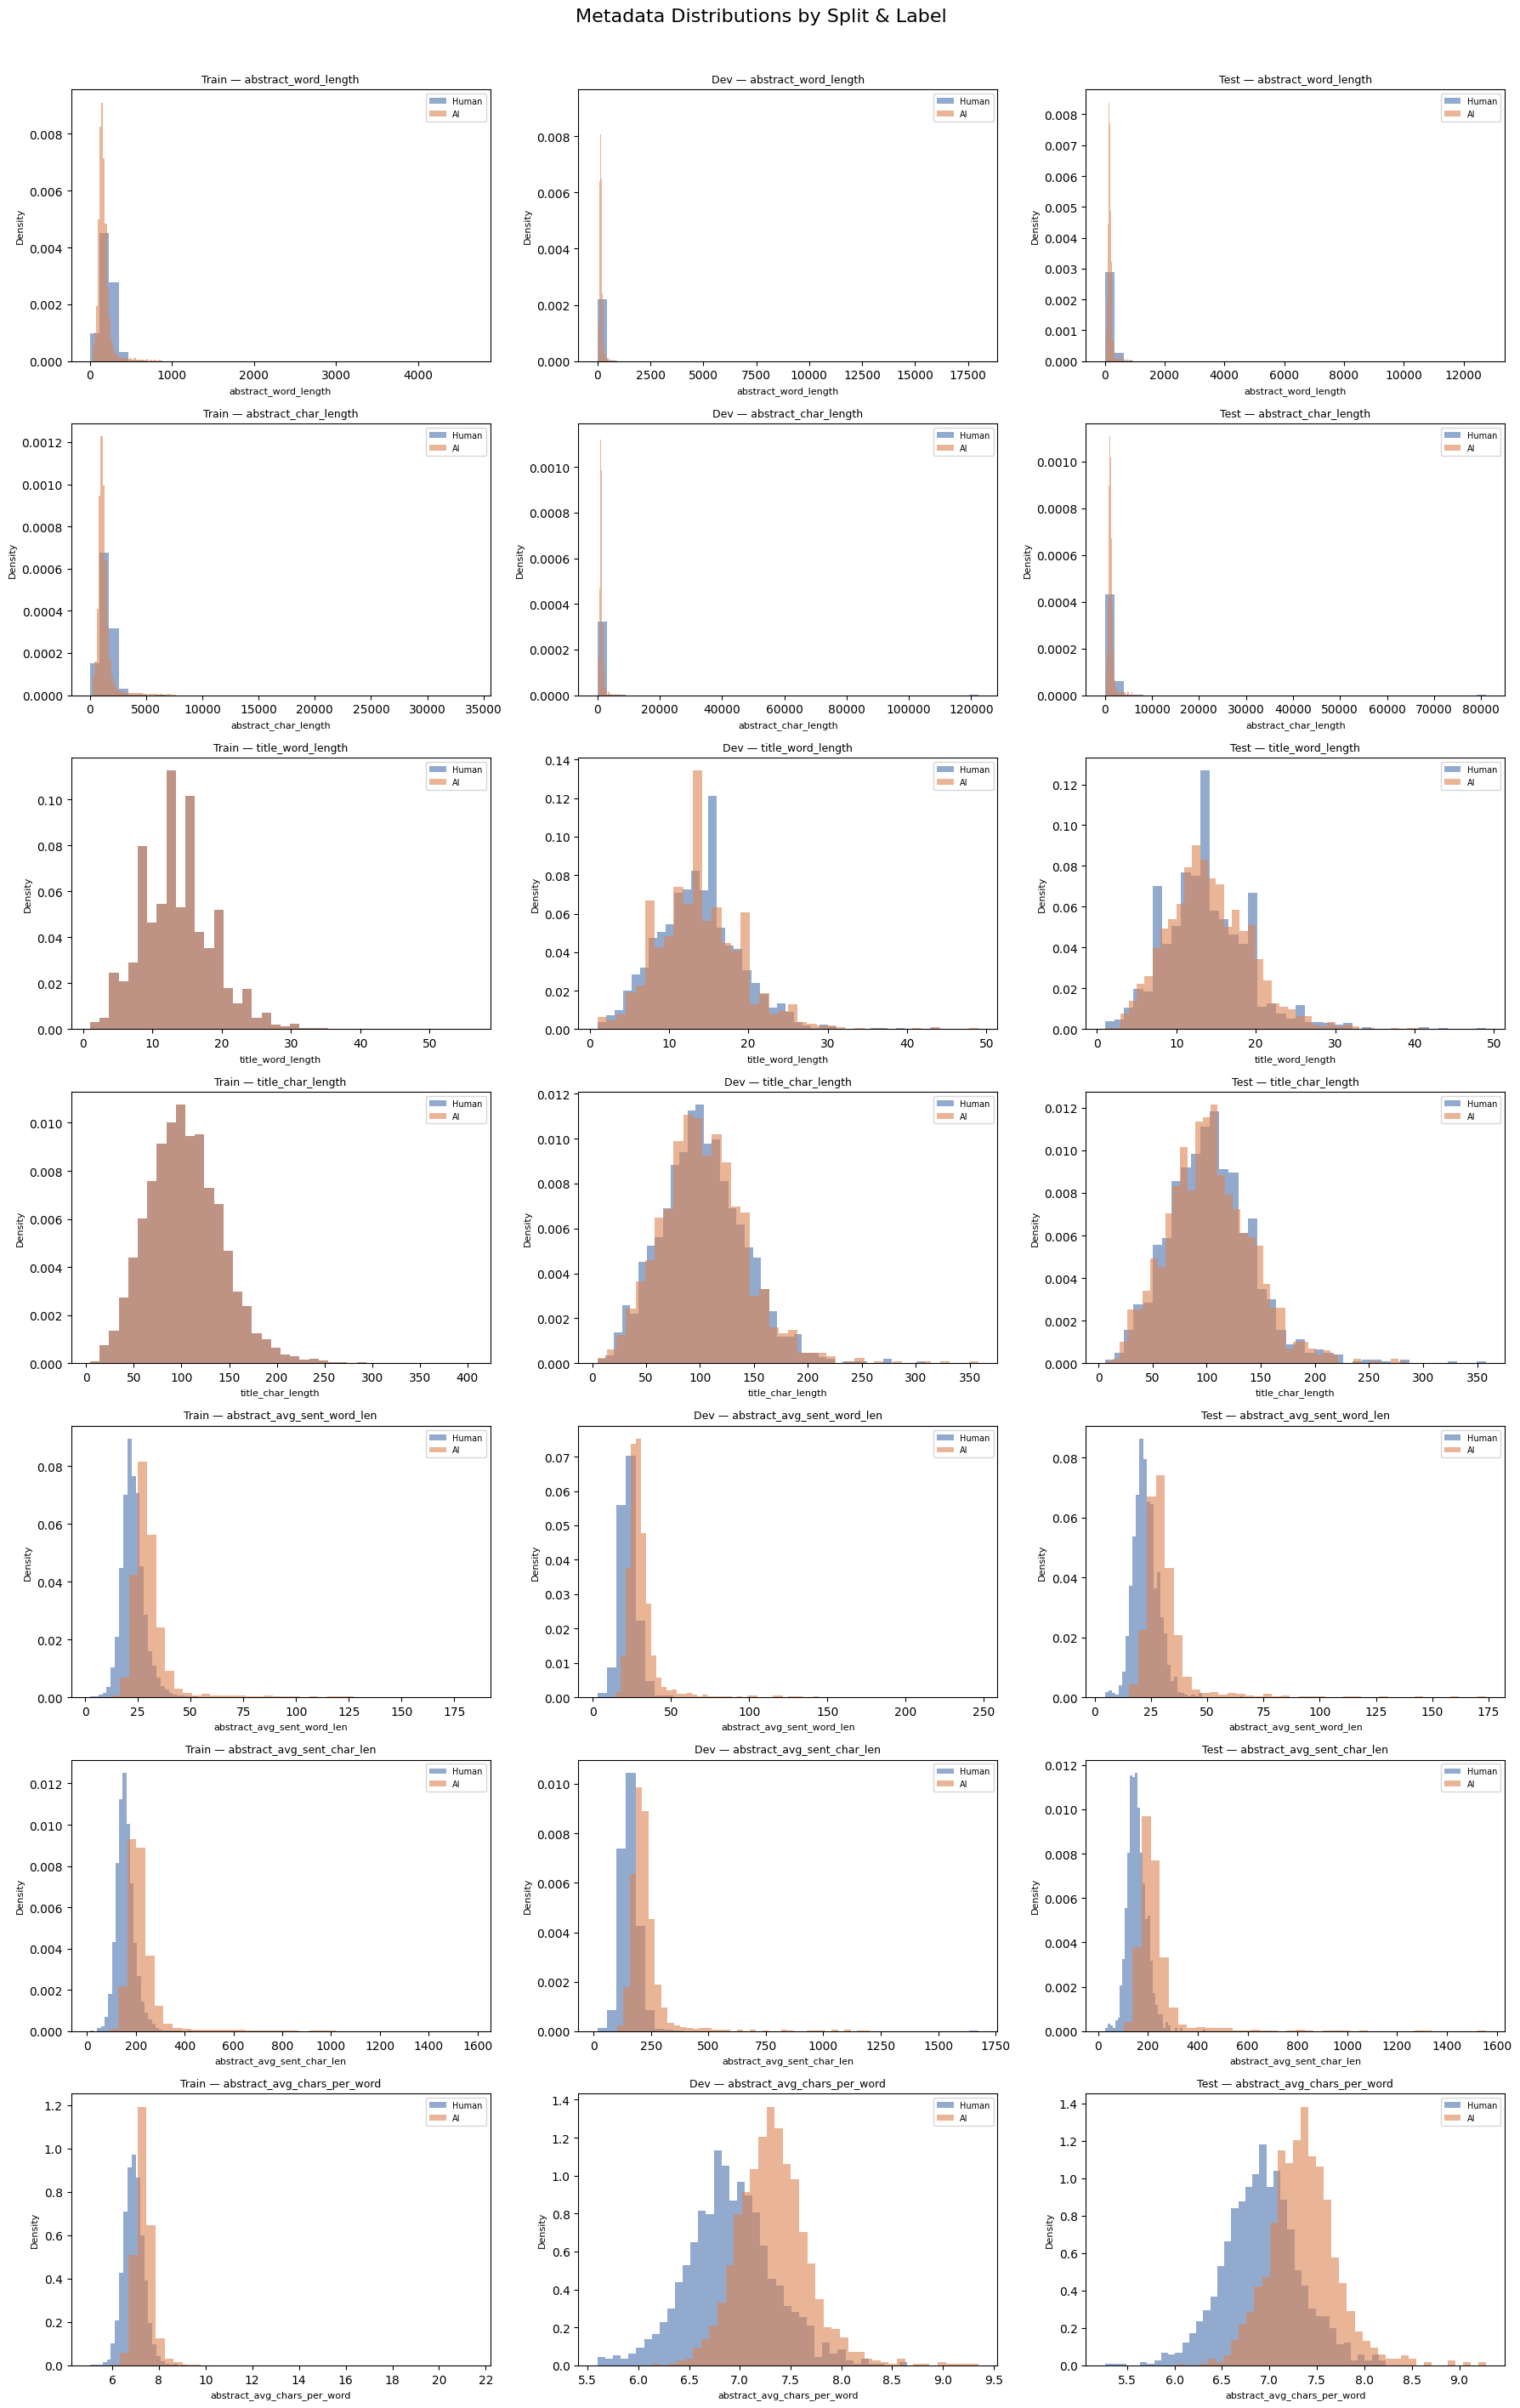

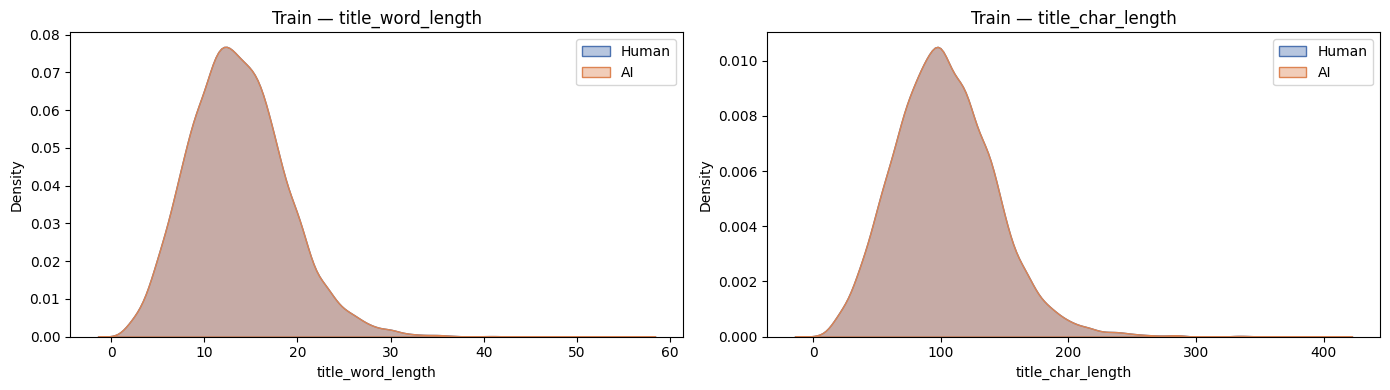

In [6]:
meta_cols = [
    'abstract_word_length', 'abstract_char_length',
    'title_word_length',    'title_char_length',
    'abstract_avg_sent_word_len', 'abstract_avg_sent_char_len',
    'abstract_avg_chars_per_word'
]

splits = {'Train': train_df, 'Dev': dev_df, 'Test': test_df}
colors = {'Human': '#4C72B0', 'AI': '#DD8452'}

fig, axes = plt.subplots(len(meta_cols), 3, figsize=(18, 4 * len(meta_cols)))
fig.suptitle('Metadata Distributions by Split & Label', fontsize=16, y=1.01)

for row, col in enumerate(meta_cols):
    for col_idx, (split_name, df) in enumerate(splits.items()):
        ax = axes[row][col_idx]
        for label_val, label_name in [(0, 'Human'), (1, 'AI')]:
            subset = df[df['label'] == label_val][col].dropna()
            ax.hist(subset, bins=40, alpha=0.6, label=label_name,
                    color=colors[label_name], density=True)
        ax.set_title(f'{split_name} — {col}', fontsize=9)
        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('metadata_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['title_word_length', 'title_char_length']):
    for label_val, label_name, color in [(0, 'Human', '#4C72B0'), (1, 'AI', '#DD8452')]:
        subset = train_df[train_df['label'] == label_val][col].dropna()
        sns.kdeplot(subset, ax=ax, label=label_name, color=color, fill=True, alpha=0.4)
    ax.set_title(f'Train — {col}')
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
# Check if titles are duplicated across labels in train
human_titles = set(train_df[train_df['label'] == 0]['title'])
ai_titles    = set(train_df[train_df['label'] == 1]['title'])

print(f"Human unique titles in train: {len(human_titles)}")
print(f"AI unique titles in train:    {len(ai_titles)}")
print(f"Titles shared across both labels in train: {len(human_titles & ai_titles)}")
print()

# Titles in test
test_human_titles = set(test_df[test_df['label'] == 0]['title'])
test_ai_titles    = set(test_df[test_df['label'] == 1]['title'])

# Titles in dev
dev_human_titles  = set(dev_df[dev_df['label'] == 0]['title'])
dev_ai_titles     = set(dev_df[dev_df['label'] == 1]['title'])

print("=== Within-split pairing (label 0 & 1 share same titles) ===")
print(f"Test  — shared titles across Human/AI: {len(test_human_titles & test_ai_titles)}")
print(f"Dev   — shared titles across Human/AI: {len(dev_human_titles & dev_ai_titles)}")

print("\n=== Cross-split leakage (titles appearing in both dev and test) ===")
all_dev_titles  = set(dev_df['title'])
all_test_titles = set(test_df['title'])
print(f"Titles in both dev and test: {len(all_dev_titles & all_test_titles)}")

print("\n=== Cross-split leakage (titles appearing in train AND dev/test) ===")
all_train_titles = set(train_df['title'])
print(f"Titles in both train and dev:  {len(all_train_titles & all_dev_titles)}")
print(f"Titles in both train and test: {len(all_train_titles & all_test_titles)}")

# Check abstracts
human_abstracts = set(train_df[train_df['label'] == 0]['abstract'])
ai_abstracts    = set(train_df[train_df['label'] == 1]['abstract'])

print()
print(f"Human unique abstracts: {len(human_abstracts)}")
print(f"AI unique abstracts:    {len(ai_abstracts)}")
print(f"Abstracts shared across both labels: {len(human_abstracts & ai_abstracts)}")

Human unique titles in train: 11465
AI unique titles in train:    11465
Titles shared across both labels in train: 11465

=== Within-split pairing (label 0 & 1 share same titles) ===
Test  — shared titles across Human/AI: 728
Dev   — shared titles across Human/AI: 728

=== Cross-split leakage (titles appearing in both dev and test) ===
Titles in both dev and test: 1410

=== Cross-split leakage (titles appearing in train AND dev/test) ===
Titles in both train and dev:  0
Titles in both train and test: 0

Human unique abstracts: 11455
AI unique abstracts:    11465
Abstracts shared across both labels: 0


# Tokenize with distilbert-base-uncased

In [22]:
from transformers import DistilBertTokenizer
from datasets import Dataset

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(df):
    ds = Dataset.from_pandas(df[['abstract', 'label']].reset_index(drop=True))
    return ds.map(
        lambda x: tokenizer(
            x['abstract'],
            padding='max_length',
            truncation=True,
            max_length=512
        ),
        batched=True
    )

train_ds = tokenize(train_df)
dev_ds   = tokenize(dev_df)
test_ds  = tokenize(test_df)

# Rename label col and set format for PyTorch
for ds in [train_ds, dev_ds, test_ds]:
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization complete.")
print(f"  Train tokens shape: {train_ds[0]['input_ids'].shape}")

Map:   0%|          | 0/22930 [00:00<?, ? examples/s]

Map:   0%|          | 0/2866 [00:00<?, ? examples/s]

Map:   0%|          | 0/2866 [00:00<?, ? examples/s]

Tokenization complete.
  Train tokens shape: torch.Size([512])


# Train and Evaluate DistilBERT, No Fine Tuning:

In [23]:
import torch
import numpy as np
from transformers import (
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- Model ---
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# Freeze the DistilBERT body — only the classification head will train, prevent fine-tuning
for param in model.distilbert.parameters():
    param.requires_grad = False

# Verify — should show only ~590K trainable out of ~67M total
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total:,} parameters')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 592,130 / 66,955,010 parameters


In [24]:
# --- Metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds)
    }

# --- Training Arguments ---
training_args = TrainingArguments(
    output_dir='./distilbert_results',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    learning_rate=8e-5,
    per_device_train_batch_size=64,  # 32 FOR MACBOOK
    per_device_eval_batch_size=128, # 64 FOR MACBOOK
    num_train_epochs=6,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='linear',
    logging_dir='./logs',
    logging_steps=50,
    fp16=torch.cuda.is_available(),   # mixed precision if GPU available
    report_to='none'
)

# --- Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,          # uses dev set for validation during training
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.227949,0.186323,0.945569
2,0.118145,0.112031,0.964061
3,0.116012,0.095444,0.970691
4,0.098165,0.083033,0.971738
5,0.097566,0.078389,0.974529
6,0.092662,0.076549,0.974878


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2154, training_loss=0.16776119119997032, metrics={'train_runtime': 717.046, 'train_samples_per_second': 191.871, 'train_steps_per_second': 3.004, 'total_flos': 1.822486470709248e+16, 'train_loss': 0.16776119119997032, 'epoch': 6.0})


=== Final Test Set Evaluation ===


=== Test Set Results ===
              precision    recall  f1-score   support

       Human       0.98      0.97      0.98      1433
          AI       0.97      0.98      0.98      1433

    accuracy                           0.98      2866
   macro avg       0.98      0.98      0.98      2866
weighted avg       0.98      0.98      0.98      2866



<Figure size 800x600 with 0 Axes>

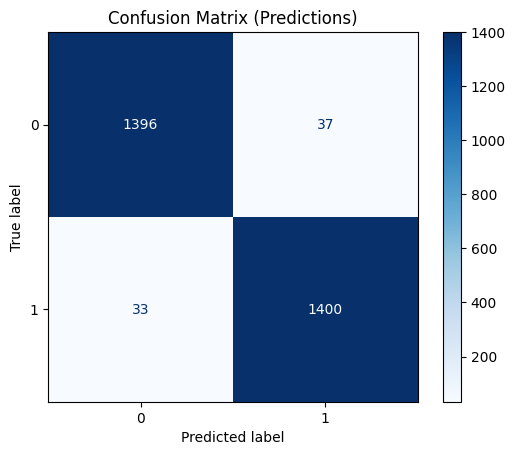

In [25]:
# --- Final Evaluation on held-out Test set ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n=== Final Test Set Evaluation ===")
predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print('=== Test Set Results ===')
print(classification_report(labels, preds, target_names=['Human', 'AI']))

# confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Predictions)')
plt.show()

In [26]:
# Attach predictions to test_df for downstream analysis (topic breakdowns, etc.)
test_df = test_df.copy() # redundant but safe
test_df['pred_0ft']  = preds
test_df['correct_0ft'] = (test_df['pred_0ft'] == test_df['label'])

# Save model
trainer.save_model('./distilbert_ai_detection/best_model_0ft')
tokenizer.save_pretrained('./distilbert_ai_detection/best_model_0ft')
print('Model saved.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


# Train and Evaluate DistilBERT, With Fine Tuning:

In [27]:
import torch
import numpy as np
from transformers import (
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- Model ---
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# Only freeze the DistilBERT embeddings layer
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False

total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total:,} parameters')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 43,119,362 / 66,955,010 parameters


In [28]:
# --- Metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds)
    }

# --- Training Arguments ---
training_args = TrainingArguments(
    output_dir='./distilbert_results',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    learning_rate=2e-5,
    per_device_train_batch_size=64,  # 32 FOR MACBOOK
    per_device_eval_batch_size=128, # 64 FOR MACBOOK
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='linear',
    logging_dir='./logs',
    logging_steps=50,
    fp16=torch.cuda.is_available(),   # mixed precision if GPU available
    report_to='none'
)

# --- Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,          # uses dev set for validation during training
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.005291,0.005140,0.998953
2,0.000548,0.006526,0.998604
3,0.000613,0.006295,0.998604


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1077, training_loss=0.04562641497780962, metrics={'train_runtime': 835.2696, 'train_samples_per_second': 82.357, 'train_steps_per_second': 1.289, 'total_flos': 9112432353546240.0, 'train_loss': 0.04562641497780962, 'epoch': 3.0})


=== Final Test Set Evaluation ===


=== Test Set Results ===
              precision    recall  f1-score   support

       Human       0.99      1.00      1.00      1433
          AI       1.00      0.99      1.00      1433

    accuracy                           1.00      2866
   macro avg       1.00      1.00      1.00      2866
weighted avg       1.00      1.00      1.00      2866



<Figure size 800x600 with 0 Axes>

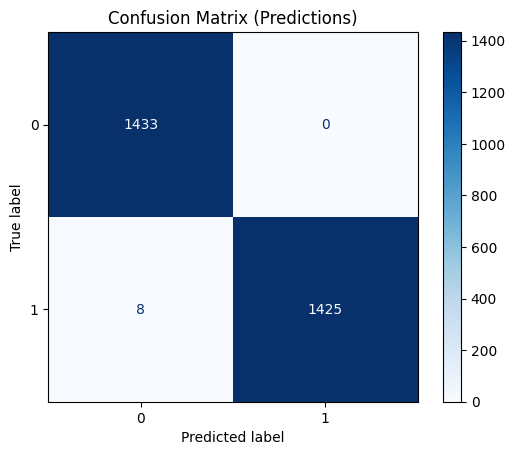

In [29]:
# --- Final Evaluation on held-out Test set ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n=== Final Test Set Evaluation ===")
predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print('=== Test Set Results ===')
print(classification_report(labels, preds, target_names=['Human', 'AI']))

# confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Predictions)')
plt.show()

In [30]:
# Attach predictions to test_df for downstream analysis (topic breakdowns, etc.)
test_df = test_df.copy() # redundant but safe
test_df['pred_1ft']  = preds
test_df['correct_1ft'] = (test_df['pred_1ft'] == test_df['label'])

# Save model
trainer.save_model('./distilbert_ai_detection/best_model_1ft')
tokenizer.save_pretrained('./distilbert_ai_detection/best_model_1ft')
print('Model saved.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


# Prepending Metadata Categories to Input

In [14]:
import pandas as pd
import numpy as np

DECILE_LABELS = [
    'very low', 'low', 'below average', 'slightly below average', 'average',
    'slightly above average', 'above average', 'high', 'very high', 'extremely high'
]

def make_decile_categorizer(train_series, col_name):
    """
    Fit decile boundaries on train data only, then return a function
    that maps any value to a labeled category based on those boundaries.
    """
    percentiles = np.linspace(0, 100, 11)  # 0, 10, 20, ..., 100
    boundaries = np.percentile(train_series.dropna(), percentiles)
    # Deduplicate boundaries (can happen if distribution is spiky)
    labels = DECILE_LABELS[:len(boundaries) - 1]  # trim if boundaries collapsed

    def categorize(series):
        return pd.cut(
            series,
            bins=boundaries,
            labels=labels,
            include_lowest=True
        ).astype(str)

    return categorize, boundaries, labels


# --- Fit categorizers on TRAIN only (avoid leakage) ---
categorize_chars_per_word, cpw_bounds, cpw_labels = make_decile_categorizer(
    train_df['abstract_avg_chars_per_word'], 'abstract_avg_chars_per_word'
)
categorize_sent_word_len, swl_bounds, swl_labels = make_decile_categorizer(
    train_df['abstract_avg_sent_word_len'], 'abstract_avg_sent_word_len'
)

# --- Apply to all splits ---
for df in [train_df, dev_df, test_df]:
    df['cat_chars_per_word']  = categorize_chars_per_word(df['abstract_avg_chars_per_word'])
    df['cat_sent_word_len']   = categorize_sent_word_len(df['abstract_avg_sent_word_len'])

# --- Preview category distributions ---
print("=== abstract_avg_chars_per_word decile boundaries ===")
for i, (lo, hi) in enumerate(zip(cpw_bounds, cpw_bounds[1:])):
    print(f"  decile_{i+1}: [{lo:.3f}, {hi:.3f}]")

print("\n=== abstract_avg_sent_word_len decile boundaries ===")
for i, (lo, hi) in enumerate(zip(swl_bounds, swl_bounds[1:])):
    print(f"  decile_{i+1}: [{lo:.2f}, {hi:.2f}]")

print("\n=== Train category counts (chars_per_word) ===")
print(train_df['cat_chars_per_word'].value_counts().sort_index())

print("\n=== Train category counts (sent_word_len) ===")
print(train_df['cat_sent_word_len'].value_counts().sort_index())

=== abstract_avg_chars_per_word decile boundaries ===
  decile_1: [5.053, 6.561]
  decile_2: [6.561, 6.765]
  decile_3: [6.765, 6.914]
  decile_4: [6.914, 7.039]
  decile_5: [7.039, 7.146]
  decile_6: [7.146, 7.251]
  decile_7: [7.251, 7.358]
  decile_8: [7.358, 7.483]
  decile_9: [7.483, 7.660]
  decile_10: [7.660, 21.371]

=== abstract_avg_sent_word_len decile boundaries ===
  decile_1: [2.36, 18.58]
  decile_2: [18.58, 20.86]
  decile_3: [20.86, 22.60]
  decile_4: [22.60, 24.20]
  decile_5: [24.20, 25.62]
  decile_6: [25.62, 27.20]
  decile_7: [27.20, 28.80]
  decile_8: [28.80, 31.00]
  decile_9: [31.00, 34.50]
  decile_10: [34.50, 183.00]

=== Train category counts (chars_per_word) ===
cat_chars_per_word
above average             2293
average                   2295
below average             2292
extremely high            2293
high                      2293
low                       2296
slightly above average    2291
slightly below average    2291
very high                 2293
ver

In [15]:
# --- Prepend metadata prefix to abstracts ---
def prepend_metadata(df):
    df = df.copy()
    df['abstract_with_meta'] = (
        "average character per word: "   + df['cat_chars_per_word']  + " || "
        "average sentence length in words: " + df['cat_sent_word_len'] + " |||| "
        + df['abstract']
    )
    return df

train_df = prepend_metadata(train_df)
dev_df   = prepend_metadata(dev_df)
test_df  = prepend_metadata(test_df)

# --- Sanity check ---
print("=== Example augmented abstract ===")
print(train_df['abstract_with_meta'].iloc[0])
print()
train_df.head(5)

=== Example augmented abstract ===
average character per word: very high || average sentence length in words: above average |||| This study focuses on the epigenetic inheritance of circadian period in clonal cells. In recent years, evidence has been emerging that implicates epigenetics as a fundamental factor driving cellular rhythms and other physiological processes within organisms. The findings from these studies indicate the potential for episodic changes to be maintained across generations via an inheritable memory embodied at a subcellular level by genetic mechanisms that operate independently of traditional Mendelian laws. Our investigations have used a novel approach to uncover how this inherited epigenetic component can affect the circadian periods of individual clonal cell lines over time. To achieve our objectives, we developed modified culture growth conditions combined with single-cell RNA sequencing techniques and chromatin immunoprecipitation assays to observe advances i

,title,abstract,label,abstract_word_length,abstract_char_length,title_word_length,title_char_length,abstract_avg_sent_word_len,abstract_avg_sent_char_len,abstract_avg_chars_per_word,cat_chars_per_word,cat_sent_word_len,abstract_with_meta
0,Epigenetic inheritance of circadian period in ...,This study focuses on the epigenetic inheritan...,1,195,1469,8,58,27.857143,209.000,7.502564,very high,above average,average character per word: very high || avera...
1,Pediatric Airway Stent Designed to Facilitate ...,Objective: The goal was to develop a pediatric...,0,239,1643,11,84,19.916667,136.000,6.828452,below average,low,average character per word: below average || a...
2,Infection prevention and control in paediatric...,Transmission of infection in the paediatric of...,0,95,723,8,62,23.750000,180.000,7.578947,very high,slightly below average,average character per word: very high || avera...
3,"Correlation between thyroid function, testoste...",STUDY DESIGN: Prospective case series. OBJECTI...,0,271,1757,15,117,16.937500,108.875,6.428044,very low,very low,average character per word: very low || averag...
4,Natural intertypic and intratypic recombinants...,This study aims to analyze the recombinant pat...,1,120,866,17,129,30.000000,215.750,7.191667,slightly above average,high,average character per word: slightly above ave...


In [31]:
# --- Re-tokenize using the augmented abstracts ---
from transformers import DistilBertTokenizer
from datasets import Dataset

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(df):
    ds = Dataset.from_pandas(df[['abstract_with_meta', 'label']].reset_index(drop=True))
    return ds.map(
        lambda x: tokenizer(
            x['abstract_with_meta'],
            padding='max_length',
            truncation=True,
            max_length=512
        ),
        batched=True
    )

train_ds = tokenize(train_df)
dev_ds   = tokenize(dev_df)
test_ds  = tokenize(test_df)

for ds in [train_ds, dev_ds, test_ds]:
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

print("Tokenization complete.")
print(f"Example token count (non-padding): {(train_ds[0]['attention_mask'] == 1).sum().item()}")
print()

# Decode the first example back to text to verify metadata prefix is present
print("\n=== Example decoded tokenized abstract ===")
print(tokenizer.decode(train_ds[0]['input_ids'], skip_special_tokens=False))

Map:   0%|          | 0/22930 [00:00<?, ? examples/s]

Map:   0%|          | 0/2866 [00:00<?, ? examples/s]

Map:   0%|          | 0/2866 [00:00<?, ? examples/s]

Tokenization complete.
Example token count (non-padding): 272


=== Example decoded tokenized abstract ===
[CLS] average character per word : very high | | average sentence length in words : above average | | | | this study focuses on the epigenetic inheritance of circadian period in clonal cells. in recent years, evidence has been emerging that implicates epigenetics as a fundamental factor driving cellular rhythms and other physiological processes within organisms. the findings from these studies indicate the potential for episodic changes to be maintained across generations via an inheritable memory embodied at a subcellular level by genetic mechanisms that operate independently of traditional mendelian laws. our investigations have used a novel approach to uncover how this inherited epigenetic component can affect the circadian periods of individual clonal cell lines over time. to achieve our objectives, we developed modified culture growth conditions combined with single - cell rn

# Train and Test on Metadata+Abstract

In [32]:
import torch
import numpy as np
from transformers import (
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- Model ---
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# See how much we can improve without fine tuning
#for param in model.distilbert.parameters():
#    param.requires_grad = False
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False

total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total:,} parameters')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable: 43,119,362 / 66,955,010 parameters


In [34]:
# --- Metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds)
    }

# --- Training Arguments ---
training_args = TrainingArguments(
    output_dir='./distilbert_results',
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    learning_rate=2e-5, # 2e-5 for fine tuning, 8e-5 for without
    per_device_train_batch_size=64,  # 32 FOR MACBOOK
    per_device_eval_batch_size=128, # 64 FOR MACBOOK
    num_train_epochs=3, # 3 for fine tuning, 6 for without
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='linear',
    logging_dir='./logs',
    logging_steps=50,
    fp16=torch.cuda.is_available(),   # mixed precision if GPU available
    report_to='none'
)

# --- Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,          # uses dev set for validation during training
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.010784,0.010356,0.997558
2,0.002365,0.006778,0.998604
3,0.000484,0.008514,0.998255


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1077, training_loss=0.04437488872305375, metrics={'train_runtime': 819.2925, 'train_samples_per_second': 83.963, 'train_steps_per_second': 1.315, 'total_flos': 9112432353546240.0, 'train_loss': 0.04437488872305375, 'epoch': 3.0})


=== Final Test Set Evaluation ===


=== Test Set Results ===
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00      1433
          AI       1.00      1.00      1.00      1433

    accuracy                           1.00      2866
   macro avg       1.00      1.00      1.00      2866
weighted avg       1.00      1.00      1.00      2866



<Figure size 800x600 with 0 Axes>

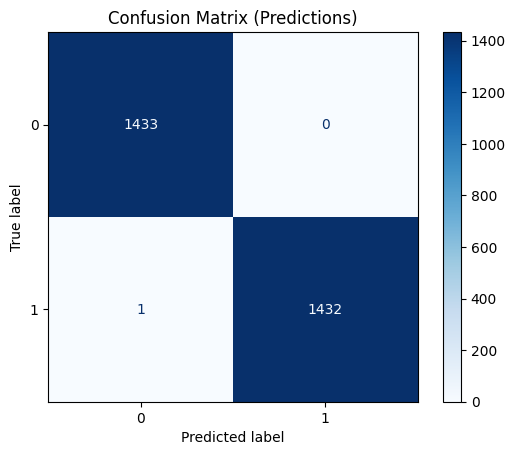

In [35]:
# --- Final Evaluation on held-out Test set ---
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n=== Final Test Set Evaluation ===")
predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print('=== Test Set Results ===')
print(classification_report(labels, preds, target_names=['Human', 'AI']))

# confusion matrix
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix (Predictions)')
plt.show()

In [36]:
# Attach predictions to test_df for downstream analysis (topic breakdowns, etc.)
test_df = test_df.copy() # redundant but safe
test_df['pred_1ft_md']  = preds
test_df['correct_1ft_md'] = (test_df['pred_1ft_md'] == test_df['label'])

#test_df['pred_0ft_md']  = preds
#test_df['correct_0ft_md'] = (test_df['pred_0ft_md'] == test_df['label'])

# Save model
trainer.save_model('./distilbert_ai_detection/best_model_1ft_md')
tokenizer.save_pretrained('./distilbert_ai_detection/best_model_1ft_md')

#trainer.save_model('./distilbert_ai_detection/best_model_0ft_md')
#tokenizer.save_pretrained('./distilbert_ai_detection/best_model_0ft_md')
print('Model saved.')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


# Error Inspection

In [37]:
# Confirm one updated test_df with results from all models
test_df.head()

,title,abstract,label,abstract_word_length,abstract_char_length,title_word_length,title_char_length,abstract_avg_sent_word_len,abstract_avg_sent_char_len,abstract_avg_chars_per_word,...,correct_0ft,cat_chars_per_word,cat_sent_word_len,abstract_with_meta,pred_0ft_md,correct_0ft_md,pred_1ft,correct_1ft,pred_1ft_md,correct_1ft_md
0,An siRNA screen for ATG protein depletion reve...,Autophagy is a catabolic process regulated by ...,0,155,1012,21,139,22.142857,143.714286,6.490323,...,True,very low,below average,average character per word: very low || averag...,0,True,0,True,0,True
1,Design and Synthesis of Novel Anti-Proliferati...,Emodin is a cell arrest and apoptosis-inducing...,0,215,1527,19,139,35.833333,253.666667,7.079070,...,True,average,extremely high,average character per word: average || average...,0,True,0,True,0,True
2,Development of a large-scale isolation chamber...,The close phylogenetic relationship between hu...,0,197,1446,20,147,24.625000,179.875000,7.304569,...,True,above average,average,average character per word: above average || a...,0,True,0,True,0,True
3,Advances in molecular phytodiagnostics – new s...,"In the last decade, developments in molecular ...",0,288,1986,10,71,28.800000,197.700000,6.864583,...,True,below average,above average,average character per word: below average || a...,0,True,0,True,0,True
4,Predictive and Reactive Distribution of Vaccin...,As recently pointed out by the Institute of Me...,0,141,997,12,104,20.142857,141.571429,7.028369,...,True,slightly below average,low,average character per word: slightly below ave...,0,True,0,True,0,True


In [38]:
# Compare performance of the 3 models
test_errors_df = test_df[
    (test_df['correct_0ft'] == False) |
    (test_df['correct_1ft'] == False) |
    (test_df['correct_1ft_md'] == False) |
    (test_df['correct_0ft_md'] == False)
]

test_errors_df_all = test_df[
    ~test_df['correct_0ft'] & ~test_df['correct_1ft'] & ~test_df['correct_1ft_md'] & ~test_df['correct_0ft_md']
]

print(f"Errors (any model wrong):  {len(test_errors_df)}")
print(f"Errors (all models wrong): {len(test_errors_df_all)}")
print(f"Total test samples:        {len(test_df)}")

test_errors_df.head()

Errors (any model wrong):  102
Errors (all models wrong): 1
Total test samples:        2866


,title,abstract,label,abstract_word_length,abstract_char_length,title_word_length,title_char_length,abstract_avg_sent_word_len,abstract_avg_sent_char_len,abstract_avg_chars_per_word,...,correct_0ft,cat_chars_per_word,cat_sent_word_len,abstract_with_meta,pred_0ft_md,correct_0ft_md,pred_1ft,correct_1ft,pred_1ft_md,correct_1ft_md
51,Plasticity for colour adaptation in vertebrate...,This paper discusses the evolution of three im...,1,128,958,17,108,25.600000,190.800000,7.453125,...,True,high,average,average character per word: high || average se...,0,False,1,True,1,True
55,Relationship Between Compassion Fatigue in Nur...,This research was conducted in order to examin...,0,157,1045,14,98,22.428571,148.428571,6.617834,...,False,low,below average,average character per word: low || average sen...,1,False,0,True,0,True
94,Spotted fever rickettsioses causing myocarditi...,"""Spotted fever rickettsioses (SFR) are severe ...",1,128,955,12,79,18.285714,135.571429,7.414063,...,False,high,very low,average character per word: high || average se...,0,False,1,True,1,True
113,How to Avoid a No-Deal ER Exit,The Brexit negotiations have been exceedingly ...,1,155,1043,7,30,25.833333,173.000000,6.696774,...,False,low,slightly above average,average character per word: low || average sen...,0,False,1,True,1,True
134,Molecular surveillance for avian influenza A v...,An investigation of the presence of influenza ...,0,89,615,12,93,29.666667,204.333333,6.887640,...,False,below average,high,average character per word: below average || a...,1,False,0,True,0,True


In [39]:
# Hardest examples across the 3 models
print(test_errors_df_all.iloc[0]['abstract_with_meta'])

test_errors_df_all.head()

average character per word: low || average sentence length in words: extremely high |||| The speed of locomotion is a fundamental part of the daily lives of many animals, allowing them to escape danger, forage for food and cover large distances with great efficiency. The persistent sodium current (I$_{NaP}$) has been studied for its role in regulating a variety of motor behaviors such as motor axon conduction velocity and nerve terminal excitability; however, the manner in which I$_{NaP}$ works together with the M-current (I${M}$) to set the speed of locomotion remains unknown. In this study, we reveal how I${M}$, an inwardly rectifying potassium current prevalent across species, synergizes with I$_{NaP}$, initiating a shift towards activated states when permeable at low voltages. Working within well-defined system parameters that involve muscle control boundaries on activity levels allows us to better understand how these two currents function in tandem to set locomotive speeds at bio

,title,abstract,label,abstract_word_length,abstract_char_length,title_word_length,title_char_length,abstract_avg_sent_word_len,abstract_avg_sent_char_len,abstract_avg_chars_per_word,...,correct_0ft,cat_chars_per_word,cat_sent_word_len,abstract_with_meta,pred_0ft_md,correct_0ft_md,pred_1ft,correct_1ft,pred_1ft_md,correct_1ft_md
2346,The M-current works in tandem with the persist...,The speed of locomotion is a fundamental part ...,1,140,937,16,95,35.0,233.5,6.671429,...,False,low,extremely high,average character per word: low || average sen...,0,False,0,False,0,False


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=963958158be4a299c830d7d23ca6fab2927c42abb26bd849ffda0c97ac618333
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

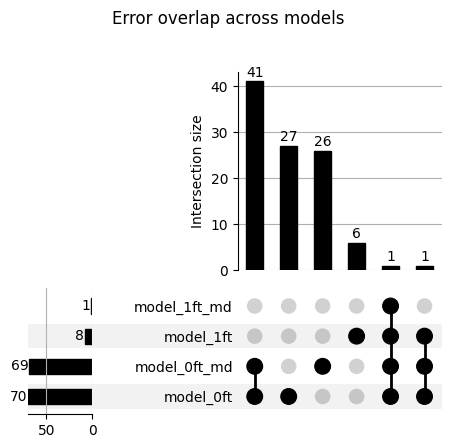

In [40]:
# UpSet plot
!pip install upsetplot

import upsetplot
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# Build membership series — each error row belongs to one or more "sets"
def get_error_memberships(df):
    memberships = []
    for _, row in df.iterrows():
        member = []
        if not row['correct_0ft']:     member.append('model_0ft')
        if not row['correct_1ft']:     member.append('model_1ft')
        if not row['correct_1ft_md']:  member.append('model_1ft_md')
        if not row['correct_0ft_md']:  member.append('model_0ft_md')
        if member:
            memberships.append(member)
    return memberships

memberships = get_error_memberships(test_df)
data = from_memberships(memberships)

fig = plt.figure(figsize=(10, 5))
upset = UpSet(data, subset_size='count', show_counts=True, sort_by='cardinality')
upset.plot(fig)
plt.suptitle('Error overlap across models', y=1.02)
plt.savefig('upset_errors.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Check title
title_counts = test_errors_df['title'].value_counts()

print(f"Total rows:       {len(test_errors_df)}")
print(f"Unique titles:    {test_errors_df['title'].nunique()}")
print(f"Repeated titles:  {(title_counts > 1).sum()}")
print()
print("=== Titles appearing more than once ===")
print(title_counts[title_counts > 1])
print()

# Check which titles have only one of their pair in the error set
paired   = title_counts[title_counts == 2].index  # both labels misclassified
unpaired = title_counts[title_counts == 1].index  # only one label misclassified

print(f"Titles (in test_errors_df) where BOTH human+AI were misclassified: {len(paired)}")
print(f"Titles (in test_errors_df) where only ONE label was misclassified:  {len(unpaired)}")

Total rows:       102
Unique titles:    102
Repeated titles:  0

=== Titles appearing more than once ===
Series([], Name: count, dtype: int64)

Titles (in test_errors_df) where BOTH human+AI were misclassified: 0
Titles (in test_errors_df) where only ONE label was misclassified:  102


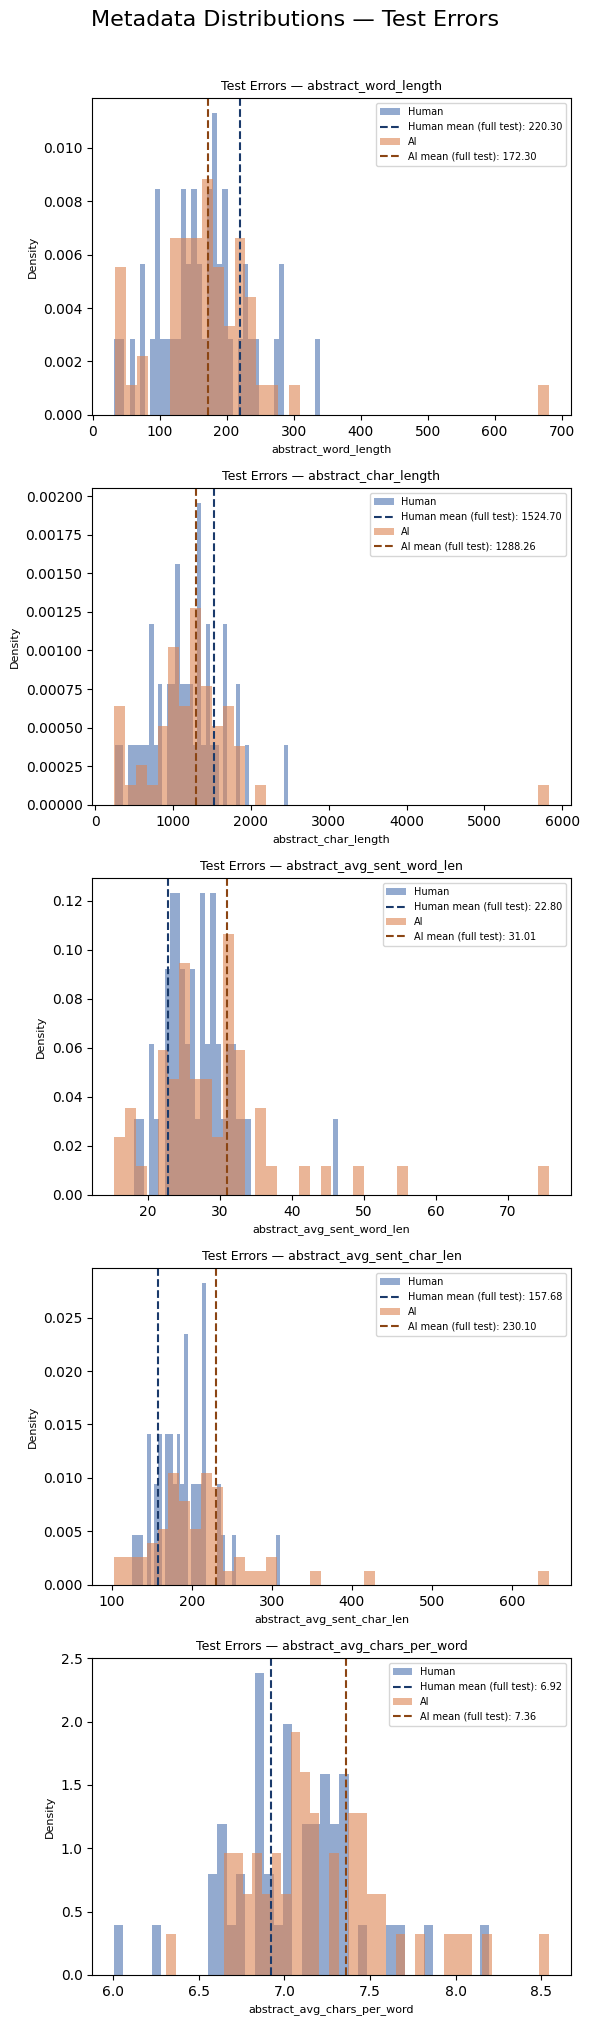

In [42]:
# How does abstract length etc. impact classification difficulty
meta_cols = [
    'abstract_word_length', 'abstract_char_length',
    'abstract_avg_sent_word_len', 'abstract_avg_sent_char_len',
    'abstract_avg_chars_per_word'
]

splits = {'Test Errors': test_errors_df}
colors = {'Human': '#4C72B0', 'AI': '#DD8452'}
mean_colors = {'Human': '#1a3a6b', 'AI': '#8B4513'}  # darker shades for the lines

n_splits = len(splits)

fig, axes = plt.subplots(len(meta_cols), n_splits, figsize=(6 * n_splits, 4 * len(meta_cols)))
fig.suptitle('Metadata Distributions — Test Errors', fontsize=16, y=1.01)

for row, col in enumerate(meta_cols):
    for col_idx, (split_name, df) in enumerate(splits.items()):
        ax = axes[row] if n_splits == 1 else axes[row][col_idx]

        for label_val, label_name in [(0, 'Human'), (1, 'AI')]:
            # Histogram for error df
            subset = df[df['label'] == label_val][col].dropna()
            ax.hist(subset, bins=40, alpha=0.6, label=label_name,
                    color=colors[label_name], density=True)

            # Vertical mean line from full test_df
            full_mean = test_df[test_df['label'] == label_val][col].mean()
            ax.axvline(
                full_mean,
                color=mean_colors[label_name],
                linestyle='--',
                linewidth=1.5,
                label=f'{label_name} mean (full test): {full_mean:.2f}'
            )

        ax.set_title(f'{split_name} — {col}', fontsize=9)
        ax.set_xlabel(col, fontsize=8)
        ax.set_ylabel('Density', fontsize=8)
        ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('metadata_distributions_errors.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# Assessing model confidence
import torch.nn.functional as F
import torch

# --- Get probabilities from logits ---
predictions = trainer.predict(test_ds)
logits = torch.tensor(predictions.predictions)
probs  = F.softmax(logits, dim=-1).numpy()  # shape: (n_samples, 2)

# probs[:,0] = P(Human), probs[:,1] = P(AI)
test_df['prob_human'] = probs[:, 0]
test_df['prob_ai']    = probs[:, 1]
test_df['confidence'] = probs.max(axis=1)  # confidence in whichever class was predicted

In [47]:
# --- Top 10 most confidently predicted AI ---
top_ai = (
    test_df[test_df['pred_1ft_md'] == 1]          # predicted AI
    .nlargest(10, 'prob_ai')
    [['abstract_with_meta', 'label', 'pred_1ft_md', 'prob_ai', 'prob_human']]
)

# --- Top 10 most confidently predicted Human ---
top_human = (
    test_df[test_df['pred_1ft_md'] == 0]          # predicted Human
    .nlargest(10, 'prob_human')
    [['abstract_with_meta', 'label', 'pred_1ft_md', 'prob_ai', 'prob_human']]
)

print("=== Top 10 most confident AI predictions ===")
print(top_ai[['label', 'pred_1ft_md', 'prob_ai']].to_string())

print("\n=== Top 10 most confident Human predictions ===")
print(top_human[['label', 'pred_1ft_md', 'prob_human']].to_string())

# --- Accuracy check on these 20 examples ---
top_20 = pd.concat([top_ai, top_human])

correct = (top_20['label'] == top_20['pred_1ft_md']).sum()
print(f"\n=== Accuracy on top 20 most confident predictions ===")
print(f"Correct:  {correct} / 20")
print(f"Accuracy: {correct / 20:.1%}")

# Break down by which class it was confident about
print("\n--- AI confident predictions ---")
print(f"  Correct: {(top_ai['label'] == top_ai['pred_1ft_md']).sum()} / 10")

print("\n--- Human confident predictions ---")
print(f"  Correct: {(top_human['label'] == top_human['pred_1ft_md']).sum()} / 10")

=== Top 10 most confident AI predictions ===
      label  pred_1ft_md   prob_ai
914       1            1  0.999731
1551      1            1  0.999729
452       1            1  0.999728
2836      1            1  0.999727
2729      1            1  0.999726
189       1            1  0.999726
302       1            1  0.999725
1425      1            1  0.999725
1799      1            1  0.999725
2345      1            1  0.999725

=== Top 10 most confident Human predictions ===
      label  pred_1ft_md  prob_human
896       0            0    0.999829
419       0            0    0.999828
1341      0            0    0.999828
129       0            0    0.999827
163       0            0    0.999827
1470      0            0    0.999827
1670      0            0    0.999827
1820      0            0    0.999827
2259      0            0    0.999827
2297      0            0    0.999827

=== Accuracy on top 20 most confident predictions ===
Correct:  20 / 20
Accuracy: 100.0%

--- AI confident predic

In [48]:
# print the actual abstracts ---
print("\n=== Most confidently AI — abstracts ===")
with pd.option_context('display.max_colwidth', None):
    for i, row in top_ai.iterrows():
        print(f"\n[{i}] True label: {'AI' if row['label']==1 else 'Human'} | P(AI)={row['prob_ai']:.4f}")
        print(row['abstract_with_meta'])
        print("-" * 80)

print("\n=== Most confidently Human — abstracts ===")
with pd.option_context('display.max_colwidth', None):
    for i, row in top_human.iterrows():
        print(f"\n[{i}] True label: {'AI' if row['label']==1 else 'Human'} | P(Human)={row['prob_human']:.4f}")
        print(row['abstract_with_meta'])
        print("-" * 80)


=== Most confidently AI — abstracts ===

[914] True label: AI | P(AI)=0.9997
average character per word: above average || average sentence length in words: slightly above average |||| This article seeks to explore how the adhesin-like protein (ALP) of Spiroplasma eriocheiris interacts with epidermal growth factor (EGF) domain proteins in a lab setting to facilitate infection.

Over recent years, researchers have been concentrating efforts on discovering mechanisms that underpin microbial pathogenesis. Spiroplasma eriocheiris is an understudied species of mycoplasmas and its virulence attributes are not well understood. Recently ALP has been proposed as a key virulence element involved in S. eriocheiris infection due to its structural similarity to adhesion components found within other bacterial species, such as Escherichia coli . In particular, one ALP from S. eriocheiris was identified which may interact with EGF domain proteins for host recognition or attachment purposes during inv

In [50]:
# --- Top 10 most uncertain predictions (confidence closest to 0.5) ---
test_df['uncertainty'] = 0.5 - (test_df['confidence'] - 0.5).abs()  # highest when confidence ~ 0.5

top_uncertain = (
    test_df
    .nlargest(10, 'uncertainty')
    [['abstract_with_meta', 'label', 'pred_1ft_md', 'prob_ai', 'prob_human', 'confidence', 'uncertainty']]
)

print("=== Top 10 most uncertain predictions ===")
print(top_uncertain[['label', 'pred_1ft_md', 'prob_ai', 'prob_human', 'confidence', 'uncertainty']].to_string())

=== Top 10 most uncertain predictions ===
      label  pred_1ft_md   prob_ai  prob_human  confidence  uncertainty
1328      1            1  0.799833    0.200167    0.799833     0.200167
190       1            1  0.912592    0.087408    0.912592     0.087408
2369      1            1  0.920718    0.079282    0.920718     0.079282
2241      1            1  0.939748    0.060252    0.939748     0.060252
94        1            1  0.977349    0.022651    0.977349     0.022651
224       0            0  0.011732    0.988268    0.988268     0.011732
435       1            1  0.989389    0.010611    0.989389     0.010611
160       1            1  0.990624    0.009376    0.990624     0.009376
2440      0            0  0.009161    0.990839    0.990839     0.009161
2298      1            1  0.991828    0.008172    0.991828     0.008172


In [52]:
# --- Accuracy on most uncertain examples ---
correct_uncertain = (top_uncertain['label'] == top_uncertain['pred_1ft_md']).sum()

print(f"\n=== Accuracy on top 10 most uncertain predictions ===")
print(f"Correct:  {correct_uncertain} / 10")
print(f"Accuracy: {correct_uncertain / 10:.1%}")
print(f"Mean confidence: {top_uncertain['confidence'].mean():.4f}")
print(f"Mean uncertainty: {top_uncertain['uncertainty'].mean():.4f}")

# Break down by predicted class
for pred_class, name in [(1, 'AI'), (0, 'Human')]:
    subset = top_uncertain[top_uncertain['pred_1ft_md'] == pred_class]
    if len(subset):
        acc = (subset['label'] == subset['pred_1ft_md']).mean()
        print(f"\n  Predicted {name} (n={len(subset)}): accuracy={acc:.1%} | mean conf={subset['confidence'].mean():.4f}")


=== Accuracy on top 10 most uncertain predictions ===
Correct:  10 / 10
Accuracy: 100.0%
Mean confidence: 0.9501
Mean uncertainty: 0.0499

  Predicted AI (n=8): accuracy=100.0% | mean conf=0.9403

  Predicted Human (n=2): accuracy=100.0% | mean conf=0.9896


In [53]:
# --- print the uncertain abstracts in full ---
print("\n=== Most uncertain — abstracts ===")
with pd.option_context('display.max_colwidth', None):
    for i, row in top_uncertain.iterrows():
        pred_col = 'pred_1ft' if 'pred_1ft' in row.index else 'pred_1ft_md'
        print(f"\n[{i}] True: {'AI' if row['label']==1 else 'Human'} | "
              f"Pred: {'AI' if row[pred_col]==1 else 'Human'} | "
              f"P(AI)={row['prob_ai']:.4f} | P(Human)={row['prob_human']:.4f}")
        print(row['abstract_with_meta'])
        print("-" * 80)


=== Most uncertain — abstracts ===

[1328] True: AI | Pred: AI | P(AI)=0.7998 | P(Human)=0.2002
average character per word: very high || average sentence length in words: extremely high |||| The present era is witnessing an increased prevalence of complex infectious diseases, making it very challenging to efficiently diagnose early signs of infection.This problem is especially pressing in cases where a pathogen cannot be easily isolated from the sample material available for diagnosis.In this work,we developed and evaluated a rapid recombinase polymerase amplification (RPA) assay as a detection tool for Streptococcus pneumoniae (S.pneumoniae), an important human bacterial pathogen, directly from whole blood samples. RPA was chosen due to its capacity to detect DNA rapidly with excellent sensitivity and specificity even when using crude specimens such as whole blood enriched with PCR inhibitors including heme-containing components.We optimized our conditions by taking into account seve

In [61]:
test_df.head()

,title,abstract,label,abstract_word_length,abstract_char_length,title_word_length,title_char_length,abstract_avg_sent_word_len,abstract_avg_sent_char_len,abstract_avg_chars_per_word,...,pred_0ft_md,correct_0ft_md,pred_1ft,correct_1ft,pred_1ft_md,correct_1ft_md,prob_human,prob_ai,confidence,uncertainty
0,An siRNA screen for ATG protein depletion reve...,Autophagy is a catabolic process regulated by ...,0,155,1012,21,139,22.142857,143.714286,6.490323,...,0,True,0,True,0,True,0.999816,0.000185,0.999816,0.000184
1,Design and Synthesis of Novel Anti-Proliferati...,Emodin is a cell arrest and apoptosis-inducing...,0,215,1527,19,139,35.833333,253.666667,7.079070,...,0,True,0,True,0,True,0.999813,0.000187,0.999813,0.000187
2,Development of a large-scale isolation chamber...,The close phylogenetic relationship between hu...,0,197,1446,20,147,24.625000,179.875000,7.304569,...,0,True,0,True,0,True,0.999810,0.000190,0.999810,0.000190
3,Advances in molecular phytodiagnostics – new s...,"In the last decade, developments in molecular ...",0,288,1986,10,71,28.800000,197.700000,6.864583,...,0,True,0,True,0,True,0.999804,0.000196,0.999804,0.000196
4,Predictive and Reactive Distribution of Vaccin...,As recently pointed out by the Institute of Me...,0,141,997,12,104,20.142857,141.571429,7.028369,...,0,True,0,True,0,True,0.999809,0.000191,0.999809,0.000191


In [56]:
error_indices = test_errors_df_all.index

print("=== All-model errors with confidence scores ===")
print(f"Total: {len(error_indices)}\n")

with pd.option_context('display.max_colwidth', None):
    for i in error_indices:
        row = test_df.loc[i]
        print(f"[{i}]")
        print(f"  True label:  {'AI' if row['label'] == 1 else 'Human'}")
        print(f"  Predicted:   {'AI' if row['pred_1ft'] == 1 else 'Human'}")
        print(f"  Confidence:  {row['confidence']:.4f}")
        print(f"  P(AI):       {row['prob_ai']:.4f} | P(Human): {row['prob_human']:.4f}")
        print(f"\n  Abstract:\n  {row['abstract_with_meta']}")
        print("-" * 80)

=== All-model errors with confidence scores ===
Total: 1

[2346]
  True label:  AI
  Predicted:   Human
  Confidence:  0.9993
  P(AI):       0.0007 | P(Human): 0.9993

  Abstract:
  average character per word: low || average sentence length in words: extremely high |||| The speed of locomotion is a fundamental part of the daily lives of many animals, allowing them to escape danger, forage for food and cover large distances with great efficiency. The persistent sodium current (I$_{NaP}$) has been studied for its role in regulating a variety of motor behaviors such as motor axon conduction velocity and nerve terminal excitability; however, the manner in which I$_{NaP}$ works together with the M-current (I${M}$) to set the speed of locomotion remains unknown. In this study, we reveal how I${M}$, an inwardly rectifying potassium current prevalent across species, synergizes with I$_{NaP}$, initiating a shift towards activated states when permeable at low voltages. Working within well-define

# N-gram Masking Experiment

In [65]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# --- Pick one confidently predicted AI and one confidently predicted Human, and same for unconfident  ---
example_ai_conf    = test_df[test_df['pred_1ft_md'] == 1].nlargest(1, 'prob_ai').iloc[0]
example_human_conf = test_df[test_df['pred_1ft_md'] == 0].nlargest(1, 'prob_human').iloc[0]

example_ai_unconf    = test_df[test_df['pred_1ft_md'] == 1].nlargest(1, 'uncertainty').iloc[0]
example_human_unconf = test_df[test_df['pred_1ft_md'] == 0].nlargest(1, 'uncertainty').iloc[0]

print(f"AI example 1    | true label: {'AI' if example_ai_conf['label']==1 else 'Human'} | P(AI)={example_ai_conf['prob_ai']:.4f}")
print(f"Human example 1  | true label: {'AI' if example_human_conf['label']==1 else 'Human'} | P(Human)={example_human_conf['prob_human']:.4f}")
print(f"AI example 2    | true label: {'AI' if example_ai_unconf['label']==1 else 'Human'} | P(AI)={example_ai_unconf['prob_ai']:.4f}")
print(f"Human example 2  | true label: {'AI' if example_human_unconf['label']==1 else 'Human'} | P(Human)={example_human_unconf['prob_human']:.4f}")

AI example 1    | true label: AI | P(AI)=0.9997
Human example 1  | true label: Human | P(Human)=0.9998
AI example 2    | true label: AI | P(AI)=0.7998
Human example 2  | true label: Human | P(Human)=0.9883


In [66]:
def get_confidence(input_ids, attention_mask, model, target_class):
    """Run inference on a single (possibly masked) sequence, return log P(target_class)."""
    model.eval()
    with torch.no_grad():
        logits = model(
            input_ids=input_ids.unsqueeze(0),
            attention_mask=attention_mask.unsqueeze(0)
        ).logits
    log_probs = F.log_softmax(logits, dim=-1).squeeze()
    return log_probs[target_class].item()


def ngram_masking_experiment(text, target_class, model, tokenizer, max_n=3, device='cpu'):
    """
    For each n in 1..max_n, replace every consecutive window of n tokens with [UNK]
    and record how much the confidence in target_class drops vs. the unmasked baseline.
    Returns a dict: {n: [(ngram_string, confidence_drop), ...]}
    """
    model = model.to(device)

    # Tokenize original
    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].squeeze().to(device)       # (512,)
    attention_mask = encoding['attention_mask'].squeeze().to(device)  # (512,)

    unk_id     = tokenizer.unk_token_id
    cls_id     = tokenizer.cls_token_id
    sep_id     = tokenizer.sep_token_id
    pad_id     = tokenizer.pad_token_id
    special_ids = {cls_id, sep_id, pad_id}

    # Baseline confidence
    baseline = get_confidence(input_ids, attention_mask, model, target_class)

    # Real (non-padding) token positions, excluding [CLS] and [SEP]
    real_positions = [
        i for i in range(len(input_ids))
        if input_ids[i].item() not in special_ids
    ]

    results = {}

    for n in range(1, max_n + 1):
        ngram_scores = []

        for start in range(len(real_positions) - n + 1):
            positions = real_positions[start: start + n]

            # Mask the window
            masked_ids = input_ids.clone()
            for pos in positions:
                masked_ids[pos] = unk_id

            # Get new confidence
            new_conf = get_confidence(masked_ids, attention_mask, model, target_class)
            drop     = baseline - new_conf

            # Decode the masked n-gram (original tokens)
            ngram_tokens = tokenizer.convert_ids_to_tokens(
                [input_ids[pos].item() for pos in positions]
            )
            ngram_str = ' '.join(ngram_tokens)

            ngram_scores.append((ngram_str, drop, new_conf))

        # Sort by largest confidence drop
        ngram_scores.sort(key=lambda x: x[1], reverse=True)
        results[n] = ngram_scores

    return baseline, results


def results_to_table(baseline, results, label, top_k=10):
    """Format top_k n-grams per n into a single readable DataFrame."""
    rows = []
    for n, scores in results.items():
        for rank, (ngram, drop, new_conf) in enumerate(scores[:top_k], 1):
            rows.append({
                'n':          n,
                'rank':       rank,
                'n-gram':     ngram,
                'conf_drop':  round(drop, 6),
                'new_conf':   round(new_conf, 4),
                'baseline':   round(baseline, 4),
            })
    df = pd.DataFrame(rows)
    df.index.name = label
    return df

In [67]:
# --- Run experiment ---
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load best model (or use trainer.model if still in memory)
model = DistilBertForSequenceClassification.from_pretrained(
    './distilbert_ai_detection/best_model_1ft_md'
)

# make sure to use the right tokenizer
print("Running AI abstract masking experiment...")
baseline_ai_conf, results_ai_conf = ngram_masking_experiment(
    text=example_ai_conf['abstract_with_meta'],
    target_class=1,   # P(AI)
    model=model,
    tokenizer=tokenizer,
    max_n=3,
    device=device
)

baseline_ai_unconf, results_ai_unconf = ngram_masking_experiment(
    text=example_ai_unconf['abstract_with_meta'],
    target_class=1,   # P(AI)
    model=model,
    tokenizer=tokenizer,
    max_n=3,
    device=device
)

print("Running Human abstract masking experiment...")
baseline_human_conf, results_human_conf = ngram_masking_experiment(
    text=example_human_conf['abstract_with_meta'],
    target_class=0,   # P(Human)
    model=model,
    tokenizer=tokenizer,
    max_n=3,
    device=device
)

baseline_human_unconf, results_human_unconf = ngram_masking_experiment(
    text=example_human_unconf['abstract_with_meta'],
    target_class=0,   # P(Human)
    model=model,
    tokenizer=tokenizer,
    max_n=3,
    device=device
)

print(f"\nBaseline P(AI)    for AI examples:    {baseline_ai_conf:.4f}, {baseline_ai_unconf:.4f}")
print(f"Baseline P(Human) for Human examples: {baseline_human_conf:.4f}, {baseline_human_unconf:.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running AI abstract masking experiment...
Running Human abstract masking experiment...
Running Human abstract masking experiment...

Baseline P(AI)    for AI examples:    -0.0003, -0.2216
Baseline P(Human) for Human examples: -0.0002, -0.0119


In [68]:
experiments = {
    'AI (confident)':     (baseline_ai_conf,     results_ai_conf),
    'AI (uncertain)':     (baseline_ai_unconf,    results_ai_unconf),
    'Human (confident)':  (baseline_human_conf,   results_human_conf),
    'Human (uncertain)':  (baseline_human_unconf, results_human_unconf),
}

tables = {
    name: results_to_table(baseline, results, label=name, top_k=10)
    for name, (baseline, results) in experiments.items()
}

with pd.option_context('display.max_colwidth', None, 'display.float_format', '{:.6f}'.format):
    for name, (baseline, _) in experiments.items():
        print(f"\n{'='*60}")
        print(f"TOP N-GRAMS — {name.upper()}")
        print(f"Baseline log P: {baseline:.6f}")
        print('='*60)
        for n in [1, 2, 3]:
            print(f"\n--- {n}-gram ---")
            print(tables[name][tables[name]['n'] == n].drop(columns='n').to_string(index=False))


TOP N-GRAMS — AI (CONFIDENT)
Baseline log P: -0.000270

--- 1-gram ---
 rank  n-gram  conf_drop  new_conf  baseline
    1    this   0.000008 -0.000300 -0.000300
    2       |   0.000004 -0.000300 -0.000300
    3 article   0.000004 -0.000300 -0.000300
    4       |   0.000002 -0.000300 -0.000300
    5       |   0.000002 -0.000300 -0.000300
    6       |   0.000001 -0.000300 -0.000300
    7      or   0.000001 -0.000300 -0.000300
    8       .   0.000001 -0.000300 -0.000300
    9       .   0.000001 -0.000300 -0.000300
   10     the   0.000001 -0.000300 -0.000300

--- 2-gram ---
 rank             n-gram  conf_drop  new_conf  baseline
    1       this article   0.000019 -0.000300 -0.000300
    2             | this   0.000015 -0.000300 -0.000300
    3                | |   0.000014 -0.000300 -0.000300
    4                | |   0.000008 -0.000300 -0.000300
    5                | |   0.000007 -0.000300 -0.000300
    6      article seeks   0.000007 -0.000300 -0.000300
    7        or enhanced 

In [69]:
# Get the single all-model error
error_idx = test_errors_df_all.index[0]
example_error = test_df.loc[error_idx]

print(f"All-model error | true label: {'AI' if example_error['label']==1 else 'Human'} | "
      f"pred: {'AI' if example_error['pred_1ft_md']==1 else 'Human'} | "
      f"confidence: {example_error['confidence']:.4f}")

# Target class is whatever the model predicted (we want to see what drove the wrong prediction)
target_class = int(example_error['pred_1ft_md'])

print("\nRunning n-gram masking experiment on all-model error...")
baseline_error, results_error = ngram_masking_experiment(
    text=example_error['abstract_with_meta'],
    target_class=target_class,
    model=model,
    tokenizer=tokenizer,
    max_n=3,
    device=device
)

table_error = results_to_table(baseline_error, results_error, label='All-model error', top_k=10)

print(f"\nBaseline P({'AI' if target_class==1 else 'Human'}) = {baseline_error:.4f}")
print(f"True label: {'AI' if example_error['label']==1 else 'Human'} — model was WRONG\n")

with pd.option_context('display.max_colwidth', None, 'display.float_format', '{:.4f}'.format):
    for n in [1, 2, 3]:
        print(f"--- {n}-gram ---")
        print(table_error[table_error['n'] == n].drop(columns='n').to_string(index=False))
        print()

All-model error | true label: AI | pred: Human | confidence: 0.9993

Running n-gram masking experiment on all-model error...

Baseline P(Human) = -0.0007
True label: AI — model was WRONG

--- 1-gram ---
 rank n-gram  conf_drop  new_conf  baseline
    1      .     0.0062   -0.0069   -0.0007
    2      .     0.0049   -0.0056   -0.0007
    3      ,     0.0019   -0.0026   -0.0007
    4      ,     0.0010   -0.0017   -0.0007
    5    the     0.0009   -0.0016   -0.0007
    6      ,     0.0008   -0.0015   -0.0007
    7    the     0.0007   -0.0014   -0.0007
    8      .     0.0005   -0.0012   -0.0007
    9      ,     0.0003   -0.0010   -0.0007
   10      (     0.0002   -0.0009   -0.0007

--- 2-gram ---
 rank    n-gram  conf_drop  new_conf  baseline
    1     ##s .     0.0063   -0.0070   -0.0007
    2 . working     0.0050   -0.0057   -0.0007
    3   rates .     0.0022   -0.0029   -0.0007
    4       $ ,     0.0021   -0.0027   -0.0007
    5   set the     0.0020   -0.0027   -0.0007
    6     . the

Save Files

In [74]:
test_df.head()


,title,abstract,label,abstract_word_length,abstract_char_length,title_word_length,title_char_length,abstract_avg_sent_word_len,abstract_avg_sent_char_len,abstract_avg_chars_per_word,...,pred_0ft_md,correct_0ft_md,pred_1ft,correct_1ft,pred_1ft_md,correct_1ft_md,prob_human,prob_ai,confidence,uncertainty
0,An siRNA screen for ATG protein depletion reve...,Autophagy is a catabolic process regulated by ...,0,155,1012,21,139,22.142857,143.714286,6.490323,...,0,True,0,True,0,True,0.999816,0.000185,0.999816,0.000184
1,Design and Synthesis of Novel Anti-Proliferati...,Emodin is a cell arrest and apoptosis-inducing...,0,215,1527,19,139,35.833333,253.666667,7.079070,...,0,True,0,True,0,True,0.999813,0.000187,0.999813,0.000187
2,Development of a large-scale isolation chamber...,The close phylogenetic relationship between hu...,0,197,1446,20,147,24.625000,179.875000,7.304569,...,0,True,0,True,0,True,0.999810,0.000190,0.999810,0.000190
3,Advances in molecular phytodiagnostics – new s...,"In the last decade, developments in molecular ...",0,288,1986,10,71,28.800000,197.700000,6.864583,...,0,True,0,True,0,True,0.999804,0.000196,0.999804,0.000196
4,Predictive and Reactive Distribution of Vaccin...,As recently pointed out by the Institute of Me...,0,141,997,12,104,20.142857,141.571429,7.028369,...,0,True,0,True,0,True,0.999809,0.000191,0.999809,0.000191


In [73]:
test_df.to_csv('./distilbert_ai_detection/test_df.csv', index=False)
test_errors_df.to_csv('./distilbert_ai_detection/test_errors_df.csv', index=False)

from google.colab import files
files.download('./distilbert_ai_detection/test_df.csv')
files.download('./distilbert_ai_detection/test_errors_df.csv')

## save what else needs to be saved, like the experiment tables

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
import shutil
shutil.make_archive('distilbert_ai_detection', 'zip', './distilbert_ai_detection')

files.download('distilbert_ai_detection.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>